# Lab A
Voy a probar cosas y a ver qué pasa (data science)

In [1]:
cd ..

f:\Repos\recommender_systems


f:\Repos\recommender_systems\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
# Para no tener que reiniciar el notebook cuando cambias una clase:
%load_ext autoreload
%autoreload 2

In [3]:
from collaborative import diagnose_cold_start, print_cold_start_report
import os
import numpy as np
import polars as pl
import pandas as pd

import optuna
from surprise import SVD, SVDpp, NMF, SlopeOne, KNNBasic, KNNWithMeans, accuracy
from surprise import Dataset, Reader


from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Load data

In [4]:
train_data = pl.read_csv("./data/collaborative_filtering/train.csv")
test_data = pl.read_csv("./data/collaborative_filtering/test.csv")
train_data.head()

user,item,rating
i64,i64,f64
1,25715,7.0
1,25716,10.0
5,25851,9.0
6,25923,5.0
7,25924,6.0


In [5]:
test_data.head()

ID,user,item
i64,i64,i64
0,8117,268
1,10512,24393
2,534,1334
3,10984,6550
4,9093,22128


In [6]:
# Vamos a segmentar por tipo: 
# OK, COLD_USER, ITEM, BOTH

# 1. Vamos a sacar un eval set para hacer nuestras pruebas
# Shuffle opcional (recomendado)
train_shuffled = train_data.sample(fraction=1.0, shuffle=True, seed=42)

split_idx = int(0.8 * train_shuffled.height)

train_subset = train_shuffled[:split_idx]
eval_set = train_shuffled[split_idx:]
# Convertimos a numpy por conveniencia
train_np = train_subset.select(["user", "item", "rating"]).to_numpy()
eval_np = eval_set.select(["user", "item", "rating"]).to_numpy()
# Diagnostico
status_map, summary = diagnose_cold_start(train_np, eval_np)
print_cold_start_report(summary)

================= Cold-start diagnosis =================
  OK (user + item in train)            37,303  ( 47.8 %)
  Cold user  (user not in train)       33,059  ( 42.3 %)
  Unknown item (item not in train)      3,932  (  5.0 %)
  Both missing                          3,777  (  4.8 %)
  Total                                78,071


Idealmente esta tabla nos tiene que dar algo similar a la proporcion que vemos en test:

In [7]:
# Proporcion de test set
test_np = test_data.select(["ID", "user", "item"]).to_numpy()
status_map, summary = diagnose_cold_start(train_np, test_np)
print_cold_start_report(summary)

================= Cold-start diagnosis =================
  OK (user + item in train)            22,399  ( 51.7 %)
  Cold user  (user not in train)        3,469  (  8.0 %)
  Unknown item (item not in train)     15,596  ( 36.0 %)
  Both missing                          1,856  (  4.3 %)
  Total                                43,320


No es similar. 
Esperemos que no de problemas

In [8]:
import polars as pl
from collaborative import ColdStartStatus

def attach_status_polars(df: pl.DataFrame, status_map: dict[int, ColdStartStatus]) -> pl.DataFrame:
    # Convertimos el Enum a string (.name) para que Polars trabaje con tipo de dato String nativo
    status_list = [status_map[i].name for i in range(df.height)]
    
    return df.with_columns(
        pl.Series("status", status_list)
    )

# 1. Seleccionamos columnas originales
train_df = train_subset.select(["user", "item", "rating"])
eval_df  = eval_set.select(["user", "item", "rating"])

# 2. Preparamos el array de train (user_id, item_id, rating) -> índices 0 y 1. Esto es correcto.
train_np = train_df.to_numpy()


# Añadimos un literal 0 como ID falso en la primera posición para desplazar user e item a los índices 1 y 2.
eval_test_np = eval_df.select([pl.lit(0).alias("id"), "user", "item"]).to_numpy()
train_test_np = train_df.select([pl.lit(0).alias("id"), "user", "item"]).to_numpy()

# 4. Diagnóstico pasándole los arrays con los índices correctos
status_map_eval, summary_eval = diagnose_cold_start(train_np, eval_test_np)
status_map_train, summary_train = diagnose_cold_start(train_np, train_test_np)

# 5. Añadir columna status (ahora como string)
eval_df = attach_status_polars(eval_df, status_map_eval)
train_df = attach_status_polars(train_df, status_map_train)


def split_by_status(df: pl.DataFrame):
    return {
        "ok": df.filter(pl.col("status") == ColdStartStatus.OK.name),
        "cold_user": df.filter(pl.col("status") == ColdStartStatus.COLD_USER.name),
        "unknown_item": df.filter(pl.col("status") == ColdStartStatus.UNKNOWN_ITEM.name),
        "both": df.filter(pl.col("status") == ColdStartStatus.BOTH.name),
    }

eval_splits = split_by_status(eval_df)
train_splits = split_by_status(train_df)

eval_ok = eval_splits["ok"]
eval_cold_user = eval_splits["cold_user"]
eval_unknown_item = eval_splits["unknown_item"]
eval_both = eval_splits["both"]

train_ok = train_splits["ok"]
train_cold_user = train_splits["cold_user"]
train_unknown_item = train_splits["unknown_item"]
train_both = train_splits["both"]

def count_by_status(df: pl.DataFrame):
    return df.group_by("status").len().sort("status")

print("Eval summary (from function):", summary_eval)
print("Eval counts (from df):")
print(count_by_status(eval_df))

print("Train summary (from function):", summary_train)
print("Train counts (from df):")
print(count_by_status(train_df))

Eval summary (from function): {'ok': 45297, 'cold_user': 6657, 'unknown_item': 23249, 'both': 2868}
Eval counts (from df):
shape: (4, 2)
┌──────────────┬───────┐
│ status       ┆ len   │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ BOTH         ┆ 2868  │
│ COLD_USER    ┆ 6657  │
│ OK           ┆ 45297 │
│ UNKNOWN_ITEM ┆ 23249 │
└──────────────┴───────┘
Train summary (from function): {'ok': 312280, 'cold_user': 0, 'unknown_item': 0, 'both': 0}
Train counts (from df):
shape: (1, 2)
┌────────┬────────┐
│ status ┆ len    │
│ ---    ┆ ---    │
│ str    ┆ u32    │
╞════════╪════════╡
│ OK     ┆ 312280 │
└────────┴────────┘


# Caso facil: No falta ni el item ni el usuario

In [9]:
train_ok = train_ok.drop("status")
eval_ok = eval_ok.drop("status")

In [ ]:
import joblib
# Definir el formato de los datos
# Para poder trabajar con deep learning tenemos que pasar los IDs de 
# usuarios e items a un vector numerico continuo
folder_path = "./ml_assets"
os.makedirs(folder_path, exist_ok=True)
user_enc = LabelEncoder()
item_enc = LabelEncoder()

train_ok = train_ok.with_columns([
    pl.Series("user_idx", user_enc.fit_transform(train_ok["user"].to_numpy())),
    pl.Series("item_idx", item_enc.fit_transform(train_ok["item"].to_numpy()))
])
eval_ok = eval_ok.with_columns([
    pl.Series("user_idx", user_enc.transform(eval_ok["user"].to_numpy())),
    pl.Series("item_idx", item_enc.transform(eval_ok["item"].to_numpy()))
])

N_USERS = len(user_enc.classes_)
N_ITEMS = len(item_enc.classes_)

joblib.dump(user_enc, os.path.join(folder_path, 'user_encoder.joblib'))
joblib.dump(item_enc, os.path.join(folder_path, 'item_encoder.joblib'))

reader = Reader(rating_scale=(1, 10)) 
train_set = Dataset.load_from_df(train_ok[["user_idx", "item_idx", "rating"]].to_pandas(), reader)
eval_set = Dataset.load_from_df(eval_ok[["user_idx", "item_idx", "rating"]].to_pandas(), reader)
# 4. Preparación para entrenamiento/test
# El conjunto de entrenamiento debe ser un objeto 'Trainset' para .fit()
full_train_data = train_set.build_full_trainset()
# El conjunto de evaluación suele usarse como lista de tuplas para .test()
test_data = eval_set.construct_testset(eval_set.raw_ratings)
print(f"Dataset de entrenamiento listo con {full_train_data.n_users} usuarios.")

Dataset de entrenamiento listo con 64399 usuarios.


In [11]:
print("Train set:")
[print(f"Valor minimo de {c}: {min(train_ok[c])}") for c in train_ok.columns]
[print(f"Valor maximo de {c}: {max(train_ok[c])}") for c in train_ok.columns]
[print(f"Numero de valores diferentes en {c}: {len(train_ok[c].unique())}") for c in train_ok.columns]
print("*"*15)
print("Test set")
print("Train set:")
[print(f"Valor minimo de {c}: {min(eval_ok[c])}") for c in eval_ok.columns]
[print(f"Valor maximo de {c}: {max(eval_ok[c])}") for c in eval_ok.columns]
[print(f"Numero de valores diferentes en {c}: {len(eval_ok[c].unique())}") for c in eval_ok.columns]

Train set:
Valor minimo de user: 1
Valor minimo de item: 1
Valor minimo de rating: 1.0
Valor minimo de user_idx: 0
Valor minimo de item_idx: 0
Valor maximo de user: 77804
Valor maximo de item: 185972
Valor maximo de rating: 10.0
Valor maximo de user_idx: 64398
Valor maximo de item_idx: 146160
Numero de valores diferentes en user: 64399
Numero de valores diferentes en item: 146161
Numero de valores diferentes en rating: 10
Numero de valores diferentes en user_idx: 64399
Numero de valores diferentes en item_idx: 146161
***************
Test set
Train set:
Valor minimo de user: 1
Valor minimo de item: 4
Valor minimo de rating: 1.0
Valor minimo de user_idx: 0
Valor minimo de item_idx: 2
Valor maximo de user: 77801
Valor maximo de item: 185441
Valor maximo de rating: 10.0
Valor maximo de user_idx: 64395
Valor maximo de item_idx: 145745
Numero de valores diferentes en user: 15087
Numero de valores diferentes en item: 23492
Numero de valores diferentes en rating: 10
Numero de valores diferente

[None, None, None, None, None]

## Model Factory

### Deep Learning


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class NeuralCF(nn.Module):
    def __init__(self, n_users, n_items, embed_dim, n_layers, dropout_rate, use_bn, max_rating=10.0):
        super(NeuralCF, self).__init__()
        self.max_rating = max_rating
        # Detectar dispositivo una sola vez
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Ejecutando en : {self.device}")
        self.user_embed = nn.Embedding(n_users, embed_dim)
        self.item_embed = nn.Embedding(n_items, embed_dim)
        
        # Construcción de la MLP 
        layers = []
        input_size = embed_dim * 2
        for i in range(n_layers):
            output_size = max(8, input_size // 2)
            layers.append(nn.Linear(input_size, output_size))
            if use_bn:
                layers.append(nn.BatchNorm1d(output_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_size = output_size
        
        self.mlp = nn.Sequential(*layers)
        self.prediction = nn.Linear(input_size, 1)
        self.sigmoid = nn.Sigmoid()
        
        self.to(self.device)

    def forward(self, user_indices, item_indices):
        u = self.user_embed(user_indices)
        i = self.item_embed(item_indices)
        x = torch.cat([u, i], dim=-1)
        x = self.mlp(x)
        out = self.prediction(x)
        return self.sigmoid(out).view(-1) * self.max_rating

    def fit(self, train_set, lr, epochs, batch_size):
        self.train()
        optimizer = optim.Adam(self.parameters(), lr=lr)
        criterion = nn.MSELoss()

        u_idx, i_idx, ratings = zip(*train_set.all_ratings())
        
        users_t = torch.LongTensor(u_idx).to(self.device)
        items_t = torch.LongTensor(i_idx).to(self.device)
        ratings_t = torch.FloatTensor(ratings).to(self.device)

        dataset = TensorDataset(users_t, items_t, ratings_t)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        for epoch in range(epochs):
            for b_users, b_items, b_ratings in loader:
                optimizer.zero_grad()
                outputs = self.forward(b_users, b_items)
                loss = criterion(outputs, b_ratings)
                loss.backward()
                optimizer.step()
        return self

    def estimate(self, u, i):
        """Para compatibilidad con el método test() de Surprise"""
        self.eval()
        with torch.no_grad():
            # Importante: el input de la predicción individual también debe estar en GPU
            u_t = torch.LongTensor([u]).to(self.device)
            i_t = torch.LongTensor([i]).to(self.device)
            return self.forward(u_t, i_t).item()
    def test(self, testset):
        """
        Simula el comportamiento de model.test() de Surprise.
        Recibe una lista de tuplas (raw_user, raw_item, true_rating)
        """
        from surprise import Prediction
        self.eval()
        predictions = []
        
        with torch.no_grad():
            for (uid, iid, r_ui) in testset:
                # Intentamos predecir. Si el user/item no existe, 
                # podríamos manejarlo, pero aquí asumimos que están en el trainset.
                est = self.estimate(uid, iid)
                predictions.append(Prediction(uid, iid, r_ui, est, {}))
        return predictions

In [13]:
class RecommenderFactory:
    @staticmethod
    def get_model(trial, model_name):
        if model_name == "SVD":
            params = {
                "n_factors": trial.suggest_int("svd_n_factors", 50, 150),
                "n_epochs": trial.suggest_int("svd_n_epochs", 10, 25),
                "lr_all": trial.suggest_float("svd_lr_all", 0.001, 0.05, log=True),
                "reg_all": trial.suggest_float("svd_reg_all", 0.01, 0.1, log=True),
                "random_state": 42
            }
            return SVD(**params)

        elif model_name == "SVDpp":
            params = {
                "n_factors": trial.suggest_int("svdpp_n_factors", 10, 50),
                "n_epochs": trial.suggest_int("svdpp_n_epochs", 10, 25),
                "lr_all": trial.suggest_float("svdpp_lr_all", 0.001, 0.01),
                "cache_ratings": True
            }
            return SVDpp(**params)

        elif model_name == "NMF":
            params = {
                "n_factors": trial.suggest_int("nmf_n_factors", 10, 50),
                "n_epochs": trial.suggest_int("nmf_n_epochs", 40, 60),
                "biased": trial.suggest_categorical("nmf_biased", [True, False]),
                "random_state": 42
            }
            return NMF(**params)

        elif model_name in ["KNNBasic", "KNNWithMeans"]:
            return KNNWithMeans(
                k=trial.suggest_int("knn_k", 20, 50),
                sim_options={
                    "name": trial.suggest_categorical("sim_name", ["msd", "cosine"]),
                    "user_based": False # Cambiar a False (Item-based) suele usar menos RAM si hay menos items que users
                },
                verbose=False
            )

        elif model_name == "SlopeOne":
            return SlopeOne()

        elif model_name == "NeuralCF":
            # Hiperparámetros de Arquitectura
            embed_dim = trial.suggest_categorical("ncf_embed_dim", [16, 32, 64, 128, 256, 1_024])
            n_layers = trial.suggest_int("ncf_layers", 1, 4)
            dropout = trial.suggest_float("ncf_dropout", 0.0, 0.5)
            use_bn = trial.suggest_categorical("ncf_use_bn", [True, False])
            
            # Hiperparámetros de Entrenamiento
            lr = trial.suggest_float("ncf_lr", 1e-4, 1e-2, log=True)
            epochs = trial.suggest_int("ncf_epochs", 5, 20)
            batch_size = trial.suggest_categorical("ncf_batch_size", [128, 256, 512])

            model = NeuralCF(
                n_users=N_USERS, 
                n_items=N_ITEMS, 
                embed_dim=embed_dim,
                n_layers=n_layers,
                dropout_rate=dropout,
                use_bn=use_bn,
                max_rating=10.0
            )
            
            # Para que el método 'objective' de Optuna pueda entrenarlo uniformemente:
            # Guardamos los params de entrenamiento en el objeto o los usamos directamente
            model.fit_params = {"lr": lr, "epochs": epochs, "batch_size": batch_size}
            return model
        return None

In [14]:
def objective(trial, trainset, testset):
    # 1. Selección de modelo
    model_name = trial.suggest_categorical("model", ["SVD", "SVDpp", "NMF", "SlopeOne", "NeuralCF"])
    #model_name = "NeuralCF"
    model = RecommenderFactory.get_model(trial, model_name)
    try:
        # 2. Entrenamiento (Terminar rápido si falla memoria)
        if model_name == "NeuralCF":
            model.fit(trainset, **model.fit_params)
        else:
            model.fit(trainset)
        
        # 3. Evaluación
        predictions = model.test(testset)
        mae = accuracy.mae(predictions, verbose=False)

        # 4. REQUISITO: Solo COMPLETE si MAE <= 1
        if mae > 1.3:
            # Marcamos como podado (Pruned) para que Optuna aprenda que esta zona es mala
            raise optuna.exceptions.TrialPruned(f"MAE fuera de rango: {mae:.4f}")

        return mae
    except (MemoryError, np.core._exceptions._ArrayMemoryError):
        # Si te quedas sin RAM, avisamos a Optuna y podamos el trial
        raise optuna.exceptions.TrialPruned("[:C]: Matriz demasiado grande.")
    except Exception as e:
        # Cualquier otro error técnico (datos, etc.)
        raise optuna.TrialPruned(f"[!]: {e}")


## RUN

In [ ]:
# Asegurar que la carpeta existe para el storage
os.makedirs("./optuna", exist_ok=True)

storage_name = "sqlite:///optuna/optuna_recommender.db"
study_id = "recommender_optimization_v1" # El ID del estudio no debe ser un path

study = optuna.create_study(
    study_name=study_id,
    storage=storage_name,
    load_if_exists=True,
    direction="minimize",
    # MedianPruner ayuda a terminar rápido si el trial es peor que la media
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=3) 
)

# Ejecución
# study.optimize(
#     lambda trial: objective(trial, full_train_data, test_data), 
#     n_trials=200,
#     show_progress_bar=True
# )

# print(f"Mejor MAE: {study.best_value}")
# print(f"Mejores parámetros: {study.best_params}")

[I 2026-03-22 20:22:32,162] Using an existing study with name 'recommender_optimization_v1' instead of creating a new one.


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-03-22 20:22:38,783] Trial 563 finished with value: 1.2410163173633784 and parameters: {'model': 'SVD', 'svd_n_factors': 133, 'svd_n_epochs': 22, 'svd_lr_all': 0.005127188257720574, 'svd_reg_all': 0.0793160623702133}. Best is trial 562 with value: 1.2334647888283774.
[I 2026-03-22 20:22:43,462] Trial 564 finished with value: 1.2358300224469945 and parameters: {'model': 'SVD', 'svd_n_factors': 53, 'svd_n_epochs': 21, 'svd_lr_all': 0.006189516360859317, 'svd_reg_all': 0.07572299904648583}. Best is trial 562 with value: 1.2334647888283774.
[W 2026-03-22 20:22:44,578] Trial 565 failed with parameters: {'model': 'NMF', 'nmf_n_factors': 24, 'nmf_n_epochs': 41, 'nmf_biased': False} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "f:\Repos\recommender_systems\.venv\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\aesto\AppData\Local\Temp\ipykernel_38648\2802743620.py", 

KeyboardInterrupt: 

# Cold Start items

In [26]:
import polars as pl

# 1. Obtenemos los IDs únicos de ítems en cada conjunto
items_en_train = train_unknown_item.select("item").unique()
items_en_eval = eval_unknown_item.select("item").unique()

# 2. Buscamos la intersección (los que aparecen en ambos)
interseccion = items_en_eval.join(items_en_train, on="item", how="inner")

# 3. Reporte de resultados
n_comunes = interseccion.height
if n_comunes > 0:
    print(f" Hay {n_comunes} ítems del set de evaluación que TAMBIÉN están en el de entrenamiento.")
    print(interseccion.head(5))
else:
    print("El Cold Start de ítems es real. No hay solapamiento.")

El Cold Start de ítems es real. No hay solapamiento.


In [ ]:
reader = Reader(rating_scale=(1, 10)) 
train_full = pl.concat([train_ok[["user", "item", "rating"]], train_unknown_item[["user", "item", "rating"]]])
train_set = Dataset.load_from_df(train_full[["user", "item", "rating"]].to_pandas(), reader).build_full_trainset()
eval_set = eval_unknown_item[["user", "item", "rating"]].to_numpy().tolist()


Algoritmo baseline que emplea la media global y el sesgo de cada individuo ponderado con distintos pesos



In [81]:
from surprise import BaselineOnly
bsl_options = {
    'method': 'als',
    'n_epochs': 20,
    'reg_u': 15, # Regularización para usuarios
    'reg_i': 10  # Regularización para ítems
}

algo = BaselineOnly(bsl_options=bsl_options)

In [82]:
print("Entrenando Baseline Estimator...")
algo.fit(train_set)
print("Realizando predicciones para ítems cold start...")
predictions = algo.test(eval_set)

Entrenando Baseline Estimator...
Estimating biases using als...
Realizando predicciones para ítems cold start...


In [83]:
# 5. Evaluación de resultados
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)

# 6. Opcional: Convertir resultados de vuelta a Polars para análisis
results_df = pl.DataFrame({
    "user": [pred.uid for pred in predictions],
    "item": [pred.iid for pred in predictions],
    "actual_rating": [pred.r_ui for pred in predictions],
    "pred_rating": [pred.est for pred in predictions],
    "was_impossible": [pred.details['was_impossible'] for pred in predictions]
})

print(results_df.head())

RMSE: 1.6805
MAE:  1.2982
shape: (5, 5)
┌─────────┬──────────┬───────────────┬─────────────┬────────────────┐
│ user    ┆ item     ┆ actual_rating ┆ pred_rating ┆ was_impossible │
│ ---     ┆ ---      ┆ ---           ┆ ---         ┆ ---            │
│ f64     ┆ f64      ┆ f64           ┆ f64         ┆ bool           │
╞═════════╪══════════╪═══════════════╪═════════════╪════════════════╡
│ 75995.0 ┆ 183240.0 ┆ 7.0           ┆ 7.300905    ┆ false          │
│ 27224.0 ┆ 80154.0  ┆ 10.0          ┆ 7.679346    ┆ false          │
│ 1968.0  ┆ 68183.0  ┆ 8.0           ┆ 7.089401    ┆ false          │
│ 60322.0 ┆ 156867.0 ┆ 9.0           ┆ 8.060646    ┆ false          │
│ 4201.0  ┆ 103653.0 ┆ 5.0           ┆ 8.85674     ┆ false          │
└─────────┴──────────┴───────────────┴─────────────┴────────────────┘


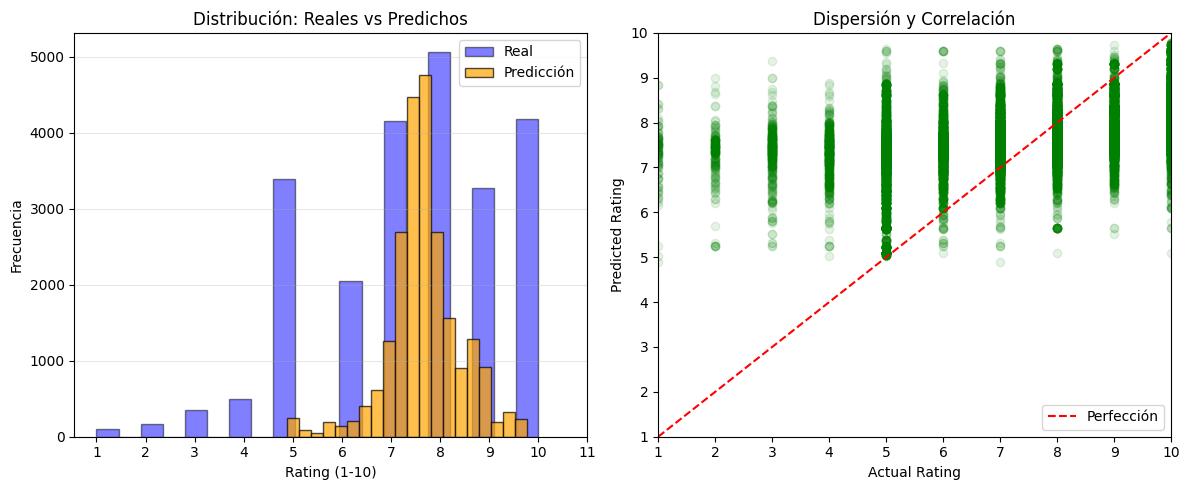

In [88]:
import matplotlib.pyplot as plt
def report_recommender_results(predictions):
    """
    Visualizaciones del error de la regresion

    """


    # 2. Convertir predicciones a DataFrame de Polars para viz
    df_viz = pl.DataFrame({
        "actual_rating": [p.r_ui for p in predictions],
        "pred_rating": [p.est for p in predictions]
    })

    # 3. Visualización: Histogramas
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1) # Dos gráficos en una fila
    plt.hist(df_viz["actual_rating"], bins=20, alpha=0.5, label='Real', color='blue', edgecolor='black')
    plt.hist(df_viz["pred_rating"], bins=20, alpha=0.7, label='Predicción', color='orange', edgecolor='black')
    plt.title('Distribución: Reales vs Predichos')
    plt.xlabel('Rating (1-10)')
    plt.ylabel('Frecuencia')
    plt.xticks(range(1, 12))
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

    # 4. Visualización: Scatter Plot
    plt.subplot(1, 2, 2)
    plt.scatter(df_viz["actual_rating"], df_viz["pred_rating"], alpha=0.1, color='green')
    plt.plot([1, 10], [1, 10], color='red', linestyle='--', label='Perfección')
    plt.title('Dispersión y Correlación')
    plt.xlabel('Actual Rating')
    plt.ylabel('Predicted Rating')
    plt.xlim(1, 10); plt.ylim(1, 10)
    plt.legend()

    plt.tight_layout()
    plt.show()

report_recommender_results(predictions)

## Busqueda de mejores parametros con optuna

In [85]:
from surprise import BaselineOnly, KNNWithMeans, accuracy
import optuna

class RecommenderFactory:
    @staticmethod
    def get_model(trial, model_name):
        if model_name == "BaselineOnly":
            # Optimizamos los parámetros de ALS (Alternating Least Squares)
            # que es el motor que calcula los sesgos (biases)
            method = trial.suggest_categorical("bsl_method", ["als", "sgd"])
            
            if method == "als":
                bsl_options = {
                    "method": "als",
                    "n_epochs": trial.suggest_int("bsl_als_epochs", 5, 30),
                    "reg_u": trial.suggest_float("bsl_reg_u", 0.01, 20.0), # Clave para Cold Start
                    "reg_i": trial.suggest_float("bsl_reg_i", 0.01, 20.0),
                }
            else: # sgd
                bsl_options = {
                    "method": "sgd",
                    "n_epochs": trial.suggest_int("bsl_sgd_epochs", 5, 30),
                    "reg": trial.suggest_float("bsl_reg_sgd", 0.001, 0.1),
                    "learning_rate": trial.suggest_float("bsl_lr", 0.0001, 0.01, log=True),
                }
            
            return BaselineOnly(bsl_options=bsl_options, verbose=False)

        # --- KNN COMO FALLBACK BASADO EN USUARIOS ---
        # Solo funciona en cold start si se configura como USER-BASED.
        # Intentará encontrar usuarios parecidos al que pide el item nuevo.
        elif model_name == "KNNWithMeans":
            sim_options = {
                "name": trial.suggest_categorical("knn_sim", ["msd", "cosine", "pearson"]),
                "user_based": True, # OBLIGATORIO: Si el item es nuevo, no podemos buscar items similares
                "min_support": trial.suggest_int("knn_min_support", 1, 5)
            }
            return KNNWithMeans(
                k=trial.suggest_int("knn_k", 10, 60),
                sim_options=sim_options,
                verbose=False
            )

        return None

# El objetivo de la optimización
def objective(trial, trainset, testset):
    # En Cold Start, solo estos dos tienen sentido en Surprise puro
    model_name = trial.suggest_categorical("model", ["BaselineOnly", "KNNWithMeans"])
    
    model = RecommenderFactory.get_model(trial, model_name)
    
    try:
        model.fit(trainset)
        predictions = model.test(testset)
        
        # Calculamos MAE
        mae = accuracy.mae(predictions, verbose=False)

        # Tu requisito de poda
        if mae > 2.5: 
            raise optuna.exceptions.TrialPruned(f"MAE demasiado alto: {mae:.4f}")

        return mae

    except Exception as e:
        raise optuna.exceptions.TrialPruned(f"Error: {e}")

#--- EJECUCIÓN ---
study_id = "recommender_optimization_unkn_items"
  
study = optuna.create_study(
      study_name=study_id,
      #storage=storage_name,
      load_if_exists=True,
      direction="minimize",
      # MedianPruner ayuda a terminar rápido si el trial es peor que la media
      pruner=optuna.pruners.MedianPruner(n_warmup_steps=10) 
)
study.optimize(lambda t: objective(t, train_set, eval_set), n_trials=50)

[I 2026-03-22 21:05:44,869] A new study created in memory with name: recommender_optimization_unkn_items
[I 2026-03-22 21:05:46,361] Trial 0 finished with value: 1.4616939020769417 and parameters: {'model': 'BaselineOnly', 'bsl_method': 'sgd', 'bsl_sgd_epochs': 14, 'bsl_reg_sgd': 0.05583433320701536, 'bsl_lr': 0.00012725674932630336}. Best is trial 0 with value: 1.4616939020769417.
[I 2026-03-22 21:05:49,330] Trial 1 finished with value: 1.317646743816025 and parameters: {'model': 'BaselineOnly', 'bsl_method': 'sgd', 'bsl_sgd_epochs': 30, 'bsl_reg_sgd': 0.04996725815711257, 'bsl_lr': 0.0009187970205875807}. Best is trial 1 with value: 1.317646743816025.
[I 2026-03-22 21:05:50,148] Trial 2 pruned. Error: Unable to allocate 15.4 GiB for an array with shape (64399, 64399) and data type int32
[I 2026-03-22 21:05:50,330] Trial 3 pruned. Error: Unable to allocate 30.9 GiB for an array with shape (64399, 64399) and data type float64
[I 2026-03-22 21:05:51,614] Trial 4 finished with value: 1.2

Re-entrenando el mejor modelo: BaselineOnly...


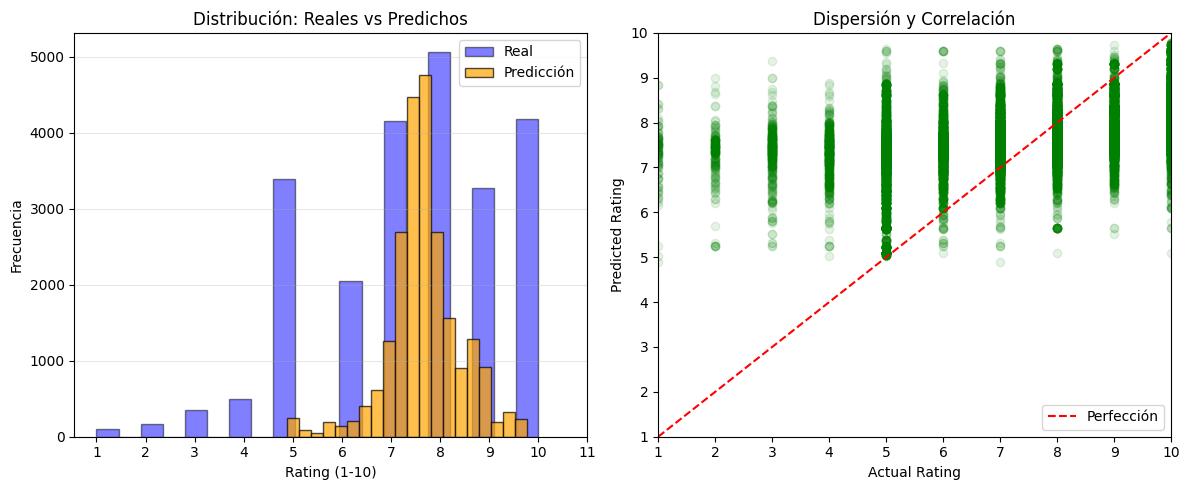

--------------------------------------------------
RESUMEN DE OPTUNA - ESTUDIO: recommender_optimization_unkn_items
--------------------------------------------------
Mejor MAE (Score): 1.2423
Mejor Modelo: BaselineOnly
Mejores Parámetros:
  - model: BaselineOnly
  - bsl_method: als
  - bsl_als_epochs: 30
  - bsl_reg_u: 1.5977262341686145
  - bsl_reg_i: 11.922593692887155
--------------------------------------------------


In [90]:
best_params = study.best_params
model_name = best_params.pop("model")
print(f"Re-entrenando el mejor modelo: {model_name}...")
best_model = RecommenderFactory.get_model(study.best_trial, model_name)
best_model.fit(train_set)

# 3. Generar predicciones finales sobre el set de evaluación
final_predictions = best_model.test(eval_set)
report_recommender_results(predictions)
print("-" * 50)
print(f"RESUMEN DE OPTUNA - ESTUDIO: {study.study_name}")
print("-" * 50)
print(f"Mejor MAE (Score): {study.best_value:.4f}")
print(f"Mejor Modelo: {study.best_params.get('model', 'N/A')}")
print("Mejores Parámetros:")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")
print("-" * 50)

# Cold start users
Debería ser más facil porque hay menos users faltantes


In [ ]:
import polars as pl

# 1. Obtenemos los IDs únicos de ítems en cada conjunto
users_en_train = train_cold_user.select("user").unique()
users_en_eval = eval_cold_user.select("user").unique()

# 2. Buscamos la intersección (los que aparecen en ambos)
interseccion = users_en_eval.join(users_en_train, on="user", how="inner")

# 3. Reporte de resultados
n_comunes = interseccion.height
if n_comunes > 0:
    print(f" Hay {n_comunes} ítems del set de evaluación que TAMBIÉN están en el de entrenamiento.")
    print(interseccion.head(5))
else:
    print("El Cold Start de users es real. No hay solapamiento.")

El Cold Start de ítems es real. No hay solapamiento.


In [ ]:
reader = Reader(rating_scale=(1, 10)) 
train_full = pl.concat([train_ok[["user", "item", "rating"]], train_cold_user[["user", "item", "rating"]]])
train_set = Dataset.load_from_df(train_full[["user", "item", "rating"]].to_pandas(), reader).build_full_trainset()
eval_set = eval_cold_user[["user", "item", "rating"]].to_numpy().tolist()


In [94]:
#--- EJECUCIÓN ---
study_id = "recommender_optimization_unkn_users"
  
class RecommenderFactory:
    @staticmethod
    def get_model(trial, model_name):
        if model_name == "BaselineOnly":
            # Optimizamos los parámetros de ALS (Alternating Least Squares)
            # que es el motor que calcula los sesgos (biases)
            method = trial.suggest_categorical("bsl_method", ["als", "sgd"])
            
            if method == "als":
                bsl_options = {
                    "method": "als",
                    "n_epochs": trial.suggest_int("bsl_als_epochs", 5, 30),
                    "reg_u": trial.suggest_float("bsl_reg_u", 0.01, 20.0), # Clave para Cold Start
                    "reg_i": trial.suggest_float("bsl_reg_i", 0.01, 20.0),
                }
            else: # sgd
                bsl_options = {
                    "method": "sgd",
                    "n_epochs": trial.suggest_int("bsl_sgd_epochs", 5, 30),
                    "reg": trial.suggest_float("bsl_reg_sgd", 0.001, 0.1),
                    "learning_rate": trial.suggest_float("bsl_lr", 0.0001, 0.01, log=True),
                }
            
            return BaselineOnly(bsl_options=bsl_options, verbose=False)

        # --- KNN COMO FALLBACK BASADO EN USUARIOS ---
        # Solo funciona en cold start si se configura como USER-BASED.
        # Intentará encontrar usuarios parecidos al que pide el item nuevo.
        elif model_name == "KNNWithMeans":
            sim_options = {
                "name": trial.suggest_categorical("knn_sim", ["msd", "cosine", "pearson"]),
                "user_based": False,
                "min_support": trial.suggest_int("knn_min_support", 1, 5)
            }
            return KNNWithMeans(
                k=trial.suggest_int("knn_k", 10, 60),
                sim_options=sim_options,
                verbose=False
            )

        return None

study = optuna.create_study(
      study_name=study_id,
      #storage=storage_name,
      load_if_exists=True,
      direction="minimize",
      # MedianPruner ayuda a terminar rápido si el trial es peor que la media
      pruner=optuna.pruners.MedianPruner(n_warmup_steps=10) 
)
study.optimize(lambda t: objective(t, train_set, eval_set), n_trials=50)

[I 2026-03-22 21:26:37,847] A new study created in memory with name: recommender_optimization_unkn_users
[I 2026-03-22 21:26:37,849] Trial 0 pruned. Error: Unable to allocate 79.6 GiB for an array with shape (146161, 146161) and data type int32
[I 2026-03-22 21:26:40,537] Trial 1 finished with value: 1.3871440935716528 and parameters: {'model': 'BaselineOnly', 'bsl_method': 'sgd', 'bsl_sgd_epochs': 23, 'bsl_reg_sgd': 0.03298093365245677, 'bsl_lr': 0.00030515179826346735}. Best is trial 1 with value: 1.3871440935716528.
[I 2026-03-22 21:26:42,035] Trial 2 finished with value: 1.2619192043341938 and parameters: {'model': 'BaselineOnly', 'bsl_method': 'als', 'bsl_als_epochs': 15, 'bsl_reg_u': 5.28612883701454, 'bsl_reg_i': 10.193479348514439}. Best is trial 2 with value: 1.2619192043341938.
[I 2026-03-22 21:26:43,649] Trial 3 finished with value: 1.4265370892999927 and parameters: {'model': 'BaselineOnly', 'bsl_method': 'sgd', 'bsl_sgd_epochs': 16, 'bsl_reg_sgd': 0.04113989728782573, 'bsl

# Cold user and item

In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from surprise import Dataset, Reader, BaselineOnly, NormalPredictor
# 1. Preparación de datos
# Supongamos que train_subset y eval_both son tus DataFrames de Polars
y_real = eval_both["rating"].to_numpy()

# --- ESTRATEGIAS ESTADÍSTICAS ---
global_mean = train_subset["rating"].mean()
global_median = train_subset["rating"].median()
global_mode = train_subset["rating"].mode()[0]

# --- ESTRATEGIAS SURPRISE ---
reader = Reader(rating_scale=(1, 10))
# Entrenamos Surprise con el subconjunto disponible
train_surp = Dataset.load_from_df(
    train_subset[["user", "item", "rating"]].to_pandas(), reader
).build_full_trainset()

# Definimos los modelos
algo_bsl = BaselineOnly(bsl_options={'method': 'als', 'reg_i': 10, 'reg_u': 10}, verbose=False)
algo_norm = NormalPredictor()

algo_bsl.fit(train_surp)
algo_norm.fit(train_surp)

# Predicciones (Al ser Cold-Cold, BaselineOnly devolverá la media global optimizada)
preds_bsl = [algo_bsl.predict(str(u), str(i)).est for u, i in zip(eval_both["user"], eval_both["item"])]
preds_norm = [algo_norm.predict(str(u), str(i)).est for u, i in zip(eval_both["user"], eval_both["item"])]

# 2. Construcción de la Tabla de Resultados en Polars
results_data = {
    "Estrategia": ["Media Global", "Mediana Global", "Moda Global", "BaselineOnly (ALS)", "NormalPredictor"],
    "MAE": [
        mean_absolute_error(y_real, [global_mean] * len(y_real)),
        mean_absolute_error(y_real, [global_median] * len(y_real)),
        mean_absolute_error(y_real, [global_mode] * len(y_real)),
        mean_absolute_error(y_real, preds_bsl),
        mean_absolute_error(y_real, preds_norm)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_real, [global_mean] * len(y_real))),
        np.sqrt(mean_squared_error(y_real, [global_median] * len(y_real))),
        np.sqrt(mean_squared_error(y_real, [global_mode] * len(y_real))),
        np.sqrt(mean_squared_error(y_real, preds_bsl)),
        np.sqrt(mean_squared_error(y_real, preds_norm))
    ]
}

df_metrics = pl.DataFrame(results_data).sort("RMSE")
print(df_metrics)

shape: (5, 3)
┌────────────────────┬──────────┬──────────┐
│ Estrategia         ┆ MAE      ┆ RMSE     │
│ ---                ┆ ---      ┆ ---      │
│ str                ┆ f64      ┆ f64      │
╞════════════════════╪══════════╪══════════╡
│ Media Global       ┆ 1.574752 ┆ 1.992216 │
│ BaselineOnly (ALS) ┆ 1.574752 ┆ 1.992216 │
│ Mediana Global     ┆ 1.559623 ┆ 2.087771 │
│ Moda Global        ┆ 1.559623 ┆ 2.087771 │
│ NormalPredictor    ┆ 2.053598 ┆ 2.586739 │
└────────────────────┴──────────┴──────────┘
